In [14]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
import os
URI = os.getenv("NEO4J_URI")
AUTH_USER = os.getenv("NEO4J_USER")
AUTH_PASSWORD = os.getenv("NEO4J_PASSWORD")
from langchain_community.graphs.neo4j_graph import Neo4jGraph

graph = Neo4jGraph(
    url=URI,
    username=AUTH_USER,
    password=AUTH_PASSWORD,
    database="simplekg",
)
graph2 = Neo4jGraph(
    url=URI,
    username=AUTH_USER,
    password=AUTH_PASSWORD,
    database="llmagraphtrkg",
)
graph3 = Neo4jGraph(
    url=URI,
    username=AUTH_USER,
    password=AUTH_PASSWORD,
    database="llmakg",
)

In [15]:
query1 = """
MATCH (e)
WHERE NOT e:Chunk AND NOT e:Document
WITH count(e) AS entity_count
MATCH (e1)-[r]->(e2)
WHERE NOT e1:Chunk 
  AND NOT e1:Document
  AND NOT e2:Chunk
  AND NOT e2:Document
RETURN
  entity_count,
  count(r) AS relation_count,
  count(DISTINCT type(r)) AS relation_type_count;
"""

result1 = graph.query(query1)[0]

import pandas as pd
df1= pd.DataFrame([result1])
df1

,entity_count,relation_count,relation_type_count
0,5745,107707,278


In [16]:
query2 = """
MATCH (e)
WHERE NOT e:Chunk AND NOT e:Document
WITH count(e) AS entity_count
MATCH (e1)-[r]->(e2)
WHERE NOT e1:Chunk 
  AND NOT e1:Document
  AND NOT e2:Chunk
  AND NOT e2:Document
RETURN
  entity_count,
  count(r) AS relation_count,
  count(DISTINCT type(r)) AS relation_type_count;
"""

result2 = graph2.query(query2)[0]

df2= pd.DataFrame([result2])
df2

,entity_count,relation_count,relation_type_count
0,5345,60900,573


In [17]:
query3 = """
MATCH (e)
WHERE NOT e:Chunk AND NOT e:Doc AND NOT e:Document
WITH count(e) AS entity_count
MATCH (a)-[r]->(b)
WHERE NOT a:Chunk AND NOT a:Doc AND NOT a:Document
  AND NOT b:Chunk AND NOT b:Doc AND NOT b:Document
  AND toUpper(type(r)) <> 'MENTIONS'
RETURN
  entity_count,
  count(r) AS relation_count,
  count(DISTINCT type(r)) AS relation_type_count;
"""

result3 = graph3.query(query3)[0]

df3= pd.DataFrame([result3])
df3

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownLabelWarning} {category: UNRECOGNIZED} {title: The provided label is not in the database.} {description: One of the labels in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing label name is: Document)} {position: line: 5, column: 43, offset: 187} for query: "\nMATCH (e)\nWHERE NOT e:Chunk AND NOT e:Doc AND NOT e:Document\nWITH count(e) AS entity_count\nMATCH (a)-[r]->(b)\nWHERE NOT a:Chunk AND NOT a:Doc AND NOT a:Document\n  AND NOT b:Chunk AND NOT b:Doc AND NOT b:Document\n  AND toUpper(type(r)) <> 'MENTIONS'\nRETURN\n  entity_count,\n  count(r) AS relation_count,\n  count(DISTINCT type(r)) AS relation_type_count;\n"
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownLabelWarning} {category: UNRECOGNIZED} {

,entity_count,relation_count,relation_type_count
0,9958,197052,2579


In [18]:
df1["database"] = "SimpleKGPipeline"
df2["database"] = "LLMGraphTransformer"
df3["database"] = "SimpleLLMPathExtractor"  


In [19]:
df_all = pd.concat([df1, df2, df3], ignore_index=True)
df_all = df_all[[
    "database",
    "entity_count",
    "relation_count",
    "relation_type_count"
]]
df_all


,database,entity_count,relation_count,relation_type_count
0,SimpleKGPipeline,5745,107707,278
1,LLMGraphTransformer,5345,60900,573
2,SimpleLLMPathExtractor,9958,197052,2579


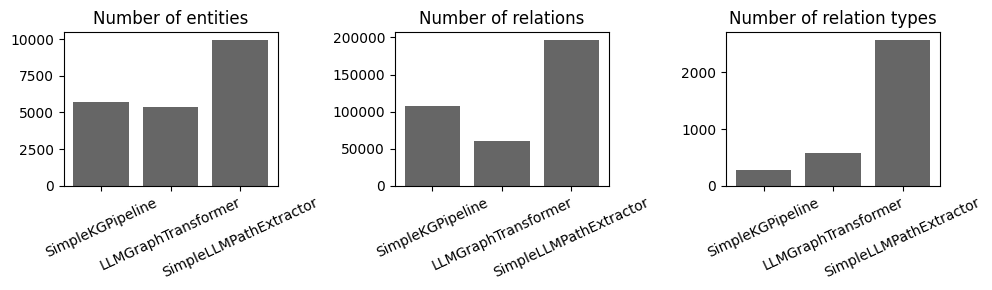

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
})


fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=False)


axes[0].bar(df_all["database"], df_all["entity_count"], color="0.4")
axes[0].set_title("Number of entities")
axes[0].tick_params(axis="x", rotation=25)


axes[1].bar(df_all["database"], df_all["relation_count"], color="0.4")
axes[1].set_title("Number of relations")
axes[1].tick_params(axis="x", rotation=25)


axes[2].bar(df_all["database"], df_all["relation_type_count"], color="0.4")
axes[2].set_title("Number of relation types")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


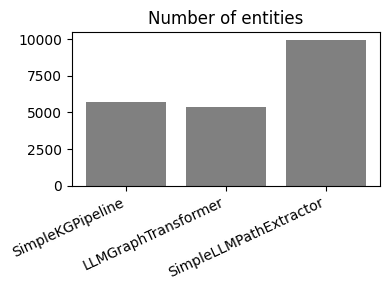

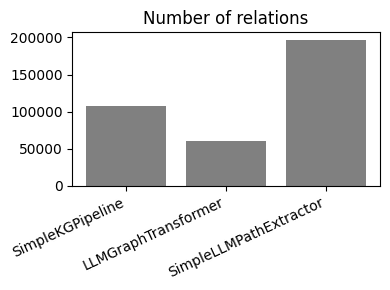

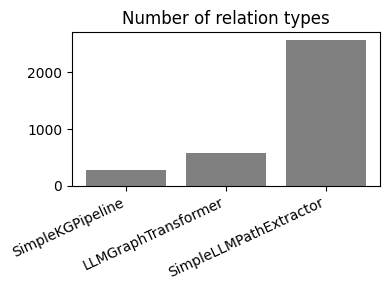

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd




plt.figure(figsize=(4, 3))
plt.bar(df_all["database"], df_all["entity_count"], color="grey")
#plt.ylabel("Number of entities")
plt.title("Number of entities", color="black")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(4, 3))
plt.bar(df_all["database"], df_all["relation_count"], color="grey")

plt.title("Number of relations")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
plt.bar(df_all["database"], df_all["relation_type_count"], color="grey")
#plt.ylabel("Number of relation types")
plt.title("Number of relation types")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
